# 03 - Feature Engineering, PCA, and Feature Selection

In [1]:
from pathlib import Path
import sys,warnings
warnings.filterwarnings("ignore")
ROOT=Path.cwd(); ROOT=ROOT.parent if ROOT.name=="notebooks" else ROOT
sys.path.insert(0,str(ROOT)) if str(ROOT) not in sys.path else None
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src.utils import *
ensure_dirs(); pd.set_option("display.max_columns",100)
print("Project root:",ROOT)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler,OrdinalEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance

Project root: /Users/sangeetasarker/Downloads/cse437-used-car-price-prediction-GROUP_NUMBER


In [2]:
df=pd.read_csv(MODEL_DATA_PATH,low_memory=False); print(df.shape); display(df.head())

(120000, 15)


,car_age,odometer,mileage_per_year,manufacturer,condition,cylinders,fuel,title_status,transmission,drive,type,paint_color,state,region,price
0,2.0,16505.0,5501.666667,infiniti,good,NaN,other,clean,other,NaN,sedan,black,sc,greenville / upstate,34990
1,4.0,27629.0,5525.800000,infiniti,good,NaN,other,clean,automatic,NaN,hatchback,blue,va,new river valley,21990
2,7.0,112959.0,14119.875000,jeep,NaN,4 cylinders,gas,clean,automatic,4wd,suv,white,ca,stockton,10888
3,6.0,66366.0,9480.857143,ram,good,8 cylinders,gas,clean,automatic,4wd,truck,silver,ak,anchorage / mat-su,29999
4,15.0,79875.0,4992.187500,acura,excellent,6 cylinders,gas,clean,automatic,fwd,sedan,black,tx,austin,7950


,component,explained_variance,cumulative
0,1,0.531370,0.531370
1,2,0.395223,0.926592
2,3,0.073408,1.000000


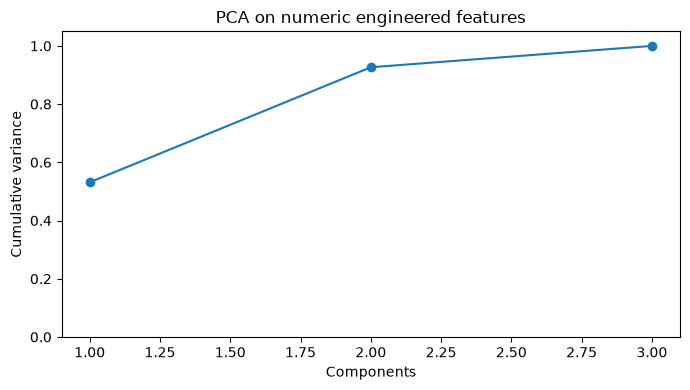

In [3]:
Xn=SimpleImputer(strategy="median").fit_transform(df[NUMERIC_FEATURES]); Xn=StandardScaler().fit_transform(Xn); pca=PCA().fit(Xn); tab=pd.DataFrame({"component":range(1,len(pca.explained_variance_ratio_)+1),"explained_variance":pca.explained_variance_ratio_,"cumulative":np.cumsum(pca.explained_variance_ratio_)}); display(tab); tab.to_csv(RESULTS_DIR/"pca_explained_variance.csv",index=False); fig,ax=plt.subplots(figsize=(7,4)); ax.plot(tab.component,tab.cumulative,marker="o"); ax.set(xlabel="Components",ylabel="Cumulative variance",ylim=(0,1.05),title="PCA on numeric engineered features"); fig.tight_layout(); fig.savefig(FIGURES_DIR/"05_pca_variance.png",dpi=160); plt.show()

In [4]:
d=df.sample(min(len(df),30000),random_state=RANDOM_STATE); X=d[FINAL_FEATURES]; y=d.price; Xtr,Xv,ytr,yv=train_test_split(X,y,test_size=.25,random_state=RANDOM_STATE); Xtr=Xtr.copy(); Xv=Xv.copy();
for c in NUMERIC_FEATURES:
 med=Xtr[c].median(); Xtr[c]=Xtr[c].fillna(med); Xv[c]=Xv[c].fillna(med)
enc=OrdinalEncoder(handle_unknown="use_encoded_value",unknown_value=-1,encoded_missing_value=-1); Xtr[CATEGORICAL_FEATURES]=enc.fit_transform(Xtr[CATEGORICAL_FEATURES].fillna("missing").astype(str)); Xv[CATEGORICAL_FEATURES]=enc.transform(Xv[CATEGORICAL_FEATURES].fillna("missing").astype(str)); rf=RandomForestRegressor(n_estimators=80,max_depth=14,min_samples_leaf=3,n_jobs=-1,random_state=RANDOM_STATE).fit(Xtr,ytr); pi=permutation_importance(rf,Xv,yv,n_repeats=3,random_state=RANDOM_STATE,scoring="neg_mean_absolute_error",n_jobs=-1); rank=pd.DataFrame({"feature":FINAL_FEATURES,"importance":pi.importances_mean}).sort_values("importance",ascending=False); display(rank); rank.to_csv(RESULTS_DIR/"feature_selection_ranking.csv",index=False)

,feature,importance
0,car_age,4241.214117
1,odometer,3682.746080
5,cylinders,1915.164645
9,drive,1490.856018
6,fuel,1277.627639
2,mileage_per_year,473.387128
3,manufacturer,424.421979
10,type,287.095050
8,transmission,268.465838
4,condition,134.415011


In [5]:
save_json({"final_features":FINAL_FEATURES,"pca_explained_variance":pca.explained_variance_ratio_,"pca_cumulative_explained_variance":np.cumsum(pca.explained_variance_ratio_),"pca_kept_in_final_pipeline":False,"reason":"Only three numeric engineered features exist; originals are retained for interpretation while categorical features are essential."},RESULTS_DIR/"feature_analysis.json"); print("Final set:",FINAL_FEATURES)

Final set: ['car_age', 'odometer', 'mileage_per_year', 'manufacturer', 'condition', 'cylinders', 'fuel', 'title_status', 'transmission', 'drive', 'type', 'paint_color', 'state', 'region']


**Decision:** PCA is demonstrated but not retained because the numeric subspace is small and original age/mileage variables are much easier to explain. Identifiers, URLs, VIN, description, image URL, unusable county, coordinates and posting timestamp are excluded.